<a href="https://colab.research.google.com/github/EmilyHong77/degentrificAItion/blob/main/ModelTraining/model_training_Emilie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import pandas as pd
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Replace 'your_dataset.csv' with your actual dataset file path
data = pd.read_csv('/content/drive/MyDrive/GentrificAItion/Montreal_data_from_census/Standardized_Census_Data/important_features.csv')

# Display the first few rows of the dataset
print(data.head())
column_name = "Population percentage change, 2001-2006 2006"

# Calculate the average of non-inf values
average_without_inf = data.loc[~data[column_name].isin([np.inf, -np.inf]), column_name].mean()

# Replace inf values with the calculated average
data['Population percentage change, 2001-2006 2006'].replace([np.inf, -np.inf], average_without_inf, inplace=True)

       ctuid  All others 2001  \
0       -1.0              0.0   
1  4620001.0           2395.0   
2  4620002.0           2595.0   
3  4620002.0           2595.0   
4  4620003.0           6065.0   

   Apartment, building that has fewer than five storeys 2001  \
0                                                0.0           
1                                             1025.0           
2                                              690.0           
3                                              690.0           
4                                             2250.0           

   Average gross rent $ 2001  Average value of dwelling $ 2001  Bicycle 2001  \
0                        0.0                               0.0           0.0   
1                      554.0                          107148.0        3010.0   
2                      528.0                          107098.0         150.0   
3                      528.0                          107098.0         150.0   
4               

In [2]:
# Convert non-numeric values to NaN in each column
columns_to_convert = data.keys()
for col in columns_to_convert:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Fill missing values with the average
for col in columns_to_convert:
    average_value = data[col].mean()
    data[col].fillna(average_value, inplace=True)

# Convert specific columns to float
data[columns_to_convert] = data[columns_to_convert].astype(float)

# Display the updated dataset
print(data.head())

       ctuid  All others 2001  \
0       -1.0              0.0   
1  4620001.0           2395.0   
2  4620002.0           2595.0   
3  4620002.0           2595.0   
4  4620003.0           6065.0   

   Apartment, building that has fewer than five storeys 2001  \
0                                                0.0           
1                                             1025.0           
2                                              690.0           
3                                              690.0           
4                                             2250.0           

   Average gross rent $ 2001  Average value of dwelling $ 2001  Bicycle 2001  \
0                        0.0                               0.0           0.0   
1                      554.0                          107148.0        3010.0   
2                      528.0                          107098.0         150.0   
3                      528.0                          107098.0         150.0   
4               

In [4]:
'''
# Check for inf values in the entire DataFrame
inf_values = data.isin([float('inf'), float('-inf')])

# Check if any column contains inf values
inf_in_columns = inf_values.any()

# Check if any row contains inf values
inf_in_rows = inf_values.any(axis=1)

# Print columns containing inf values
print("Columns containing inf values:")
print(inf_in_columns[inf_in_columns])

# Print rows containing inf values
print("\nRows containing inf values:")
print(data[inf_in_rows])
'''

'\n# Check for inf values in the entire DataFrame\ninf_values = data.isin([float(\'inf\'), float(\'-inf\')])\n\n# Check if any column contains inf values\ninf_in_columns = inf_values.any()\n\n# Check if any row contains inf values\ninf_in_rows = inf_values.any(axis=1)\n\n# Print columns containing inf values\nprint("Columns containing inf values:")\nprint(inf_in_columns[inf_in_columns])\n\n# Print rows containing inf values\nprint("\nRows containing inf values:")\nprint(data[inf_in_rows])\n'

# 1 Find Important Predictors of Gentrification

In [3]:
# specificy which columns to drop depending on what target is

# predict Gentrifiable
Gentrifiable_2021 = ["ctuid",
                     "Median total income of household in 2020 ($) 2021",
                     "Gentrified Ding 2021",
                     "Gentrified Ding 2021",
                     "Median after-tax income of household in 2020 ($) 2021"]

# predict Gentrified
Gentrified_2021 = ["ctuid",
                   "Average value of dwellings ($) 2021",
                   "Median monthly shelter costs for rented dwellings ($) 2021",
                   "Bachelor's degree or higher 2021",
                   "Gentrification Level Ding 2021"
                   ]

# predict Gentrification Level
Gen_Levels_2021 = ["ctuid",
                   "Average value of dwellings ($) 2021",
                   "Median monthly shelter costs for rented dwellings ($) 2021",
                   "Bachelor's degree or higher 2021",
                   "Gentrified Ding 2021"
                   ]


In [4]:
# drop the column that is your target
data = data.drop(Gentrifiable_2021, axis=1)
# data = data.drop(Gentrified_2021, axis=1)
# data = data.drop(Gen_Levels_2021, axis=1)

In [5]:
# Specify columns we wish the model to predict
target_column_gentrifiable_2021 = "Gentrifiable Ding 2021"
target_column_gentrified_2021 = "Gentrified Ding 2021"
target_column_gen_levels_2021 = "Gentrification Level Ding 2021"

In [6]:
# Specify which column we wish the model to predict
target_column = target_column_gentrifiable_2021
# target_column = target_column_gentrified_2021
# target_column = target_column_gen_levels_2021

'''
# Calculate the median of target column --> not necessary for Gentrified Measure
# median_target = data[target_column].median()

# Create a new binary label column --> not necessary for Gentrified Measure
# data[target_column] = (data[target_column] > median_target).astype(int)
'''

# Define features and target
X = data.drop(target_column, axis=1)
y = data[target_column]
print(y)

0       0.0
1       1.0
2       1.0
3       0.0
4       1.0
       ... 
1003    0.0
1004    0.0
1005    0.0
1006    0.0
1007    0.0
Name: Gentrifiable Ding 2021, Length: 1008, dtype: float64


In [7]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to DMatrix (XGBoost's internal data structure)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Define parameters
params = {
    'objective': 'multi:softprob',  # Specify multiclass classification
    'num_class': 2,  # NUMBER OF CLASSES 4 for Level of gentrification
    'eval_metric': 'mlogloss',  # Evaluation metric
    'max_depth': 4,  # Maximum depth of a tree
    'eta': 0.3,  # Learning rate
    'seed': 42  # Random seed for reproducibility
}

# Train the model
bst = xgb.train(params, dtrain, num_boost_round=100)

# Make predictions
y_pred_prob = bst.predict(dtest)
y_pred = y_pred_prob.argmax(axis=1)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.96


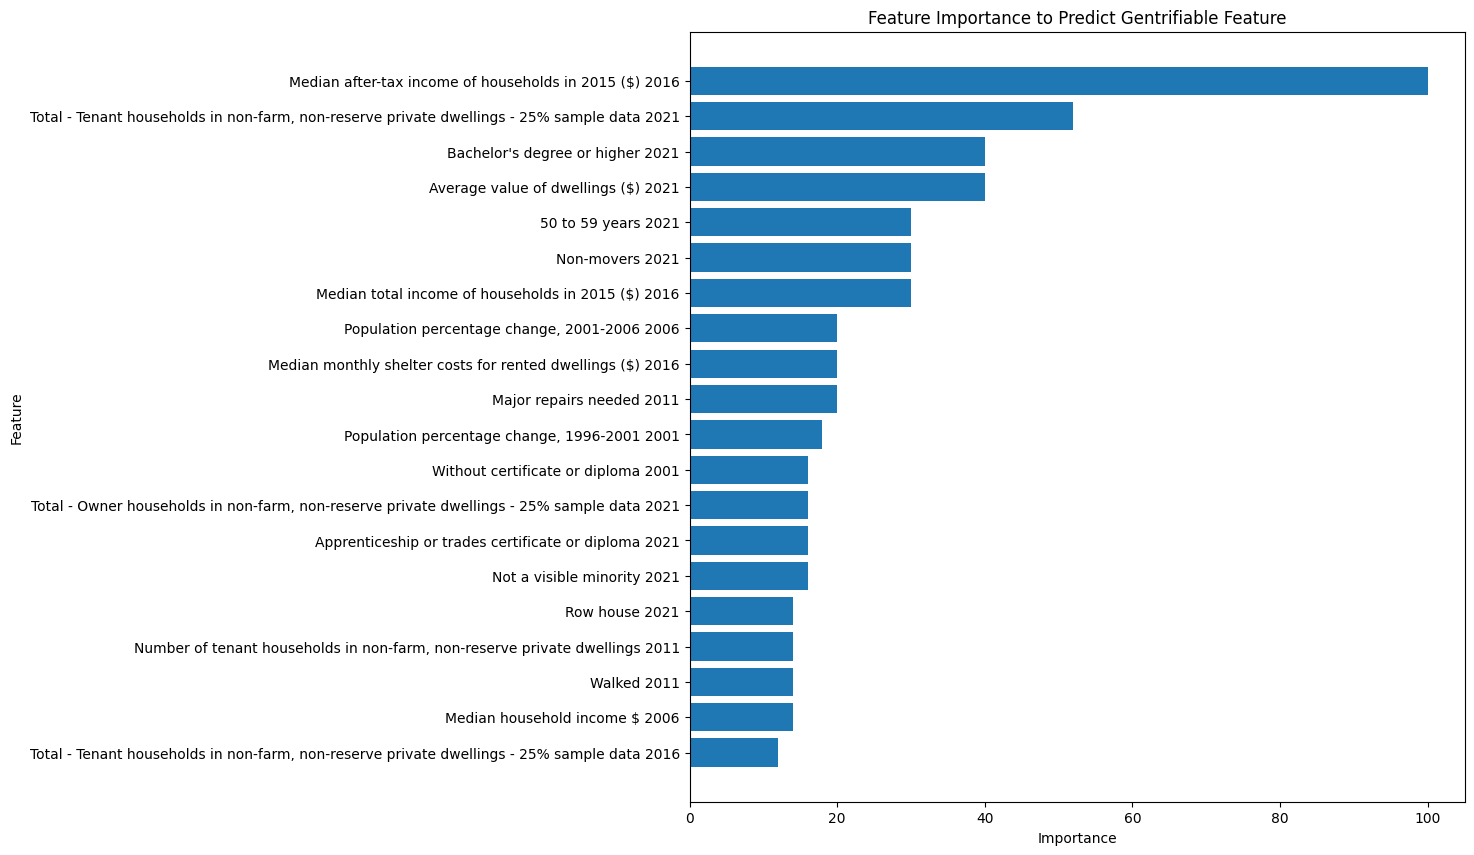

In [8]:
# Extract and plot feature importance
importance = bst.get_score(importance_type='weight')
importance_df = pd.DataFrame(importance.items(), columns=['Feature', 'Importance']).sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 10))
plt.barh(importance_df['Feature'].iloc[:20], importance_df['Importance'].iloc[:20])
plt.xlabel('Importance')
plt.ylabel('Feature')

# change title for each target
plt.title('Feature Importance to Predict Gentrifiable Feature')
plt.gca().invert_yaxis()

# Save the plot as an image file to Google Drive
plt.savefig('/content/drive/My Drive/GentrificAItion/ModelOutputs/feat_imp_2021_gentrifiable.png', bbox_inches='tight')
plt.show()
plt.close('all')

In [9]:
# Save the plot as an image file to Google Drive
plt.savefig('/content/drive/My Drive/GentrificAItion/ModelOutputs/feat_imp_2021_gentrifiable.png', bbox_inches='tight')
plt.close('all')

# 2 Predict Gentrification for 2021

# 3 Predict Gentrification for 2026